# Data filtering and visualization of TUAS's Turku South PV system

 

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pvlib

# Add the folder path to sys.path
folder_path = os.path.abspath(os.path.join('..'))
sys.path.append(folder_path)

from helpers import filters
from helpers import preprocessing
from helpers import irradiance_transpositions
from helpers import reflection_estimator
from helpers import solar_irradiance_estimator
import config

matplotlib.rcParams['font.family'] = 'arial'
plt.rc('font', size=7)

# Path to data
DATA_PATH = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Datasets')

In [2]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH, 'turku_south_UTC00.csv'), parse_dates=['utctime'])
# Get rid of old and unnecessary columns
data = data.drop(columns=['POA', 'cell_T'])
data = data.set_index('utctime')
# Get DNI and DHI
# Get solar position
# For solar position, the average temperature is required
mean_temperature = data['TEMP'].mean()

spa = pvlib.solarposition.spa_python(data.index, config.latitude_turku, config.longitude_turku,
           altitude=config.elevation_turku, pressure=101325, temperature=mean_temperature, delta_t=70,
           atmos_refract=None, how='numpy')
irrad_data = pvlib.irradiance.erbs(ghi=data['ghi'].values, zenith=spa['zenith'].values, datetime_or_doy=data.index)
# Get the POA irradiance using Perez model
data['dni'] = irrad_data['dni']
data['dhi'] = irrad_data['dhi']

data = irradiance_transpositions.irradiance_df_to_poa_df(data)
data = reflection_estimator.add_reflection_corrected_poa_components_to_df(data)
data = reflection_estimator.add_reflection_corrected_poa_to_df(data)

data = data.drop(columns=['poa'])
data = data.reset_index()
col_name_dict_turku = {'ac_power':'pv_inv_out', 'windSpeed':'wind', 'TEMP':'T', 'poa_ref_cor':'poa'}
data = data.rename(columns=col_name_dict_turku)
#data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'ghi', 'snow', 'wind', 'dataQC', 'viss_day']]
data

,utctime,power,pv_inv_out,wind,T,ghi,dni,dhi,dni_poa,dhi_poa,ghi_poa,dni_rc,dhi_rc,ghi_rc,poa
0,2018-01-03 10:25:00,0.0,0.0,1.242090,2.8400,-4.544665,0.0,-4.544665,0.0,0.0,-0.011692,0.0,0.0,-0.006786,-0.006786
1,2018-01-03 10:30:00,0.0,0.0,0.929192,2.8400,-3.936000,0.0,-3.936000,0.0,0.0,-0.010126,0.0,0.0,-0.005877,-0.005877
2,2018-01-03 10:35:00,0.0,0.0,0.927850,2.7240,-4.663835,0.0,-4.663835,0.0,0.0,-0.011998,0.0,0.0,-0.006964,-0.006964
3,2018-01-03 10:40:00,0.0,0.0,1.951310,2.7036,-4.403500,0.0,-4.403500,0.0,0.0,-0.011328,0.0,0.0,-0.006575,-0.006575
4,2018-01-03 10:45:00,0.0,0.0,1.114170,2.7504,-4.374165,0.0,-4.374165,0.0,0.0,-0.011253,0.0,0.0,-0.006532,-0.006532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272040,2020-09-17 19:35:00,0.0,0.0,1.440000,6.4400,-5.475000,0.0,-5.475000,0.0,0.0,-0.014085,0.0,0.0,-0.008175,-0.008175
272041,2020-09-17 19:40:00,0.0,0.0,0.520000,6.4100,-5.250000,0.0,-5.250000,0.0,0.0,-0.013506,0.0,0.0,-0.007839,-0.007839
272042,2020-09-17 19:45:00,0.0,0.0,2.030000,6.4000,-5.655000,0.0,-5.655000,0.0,0.0,-0.014548,0.0,0.0,-0.008444,-0.008444
272043,2020-09-17 19:50:00,0.0,0.0,1.360000,6.3000,-5.785000,0.0,-5.785000,0.0,0.0,-0.014882,0.0,0.0,-0.008638,-0.008638


In [3]:
# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa', 'power'])
data = data[data.utctime >= data_nonans.utctime.iloc[0]]
data

,utctime,power,pv_inv_out,wind,T,ghi,dni,dhi,dni_poa,dhi_poa,ghi_poa,dni_rc,dhi_rc,ghi_rc,poa
0,2018-01-03 10:25:00,0.0,0.0,1.242090,2.8400,-4.544665,0.0,-4.544665,0.0,0.0,-0.011692,0.0,0.0,-0.006786,-0.006786
1,2018-01-03 10:30:00,0.0,0.0,0.929192,2.8400,-3.936000,0.0,-3.936000,0.0,0.0,-0.010126,0.0,0.0,-0.005877,-0.005877
2,2018-01-03 10:35:00,0.0,0.0,0.927850,2.7240,-4.663835,0.0,-4.663835,0.0,0.0,-0.011998,0.0,0.0,-0.006964,-0.006964
3,2018-01-03 10:40:00,0.0,0.0,1.951310,2.7036,-4.403500,0.0,-4.403500,0.0,0.0,-0.011328,0.0,0.0,-0.006575,-0.006575
4,2018-01-03 10:45:00,0.0,0.0,1.114170,2.7504,-4.374165,0.0,-4.374165,0.0,0.0,-0.011253,0.0,0.0,-0.006532,-0.006532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272040,2020-09-17 19:35:00,0.0,0.0,1.440000,6.4400,-5.475000,0.0,-5.475000,0.0,0.0,-0.014085,0.0,0.0,-0.008175,-0.008175
272041,2020-09-17 19:40:00,0.0,0.0,0.520000,6.4100,-5.250000,0.0,-5.250000,0.0,0.0,-0.013506,0.0,0.0,-0.007839,-0.007839
272042,2020-09-17 19:45:00,0.0,0.0,2.030000,6.4000,-5.655000,0.0,-5.655000,0.0,0.0,-0.014548,0.0,0.0,-0.008444,-0.008444
272043,2020-09-17 19:50:00,0.0,0.0,1.360000,6.3000,-5.785000,0.0,-5.785000,0.0,0.0,-0.014882,0.0,0.0,-0.008638,-0.008638


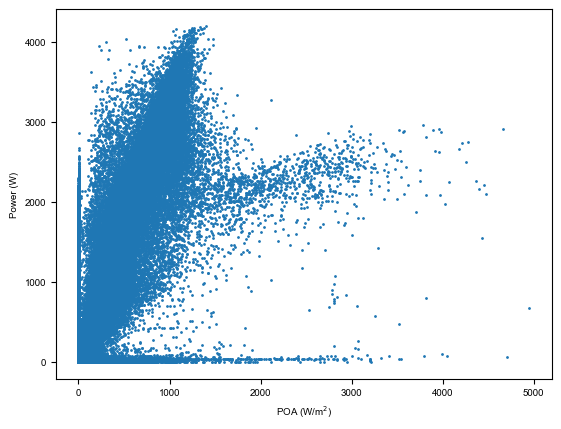

In [4]:
plt.scatter(data['poa'], data['power'], s=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')
plt.show()

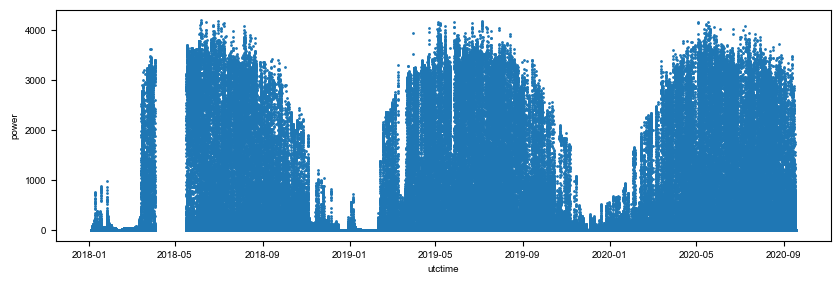

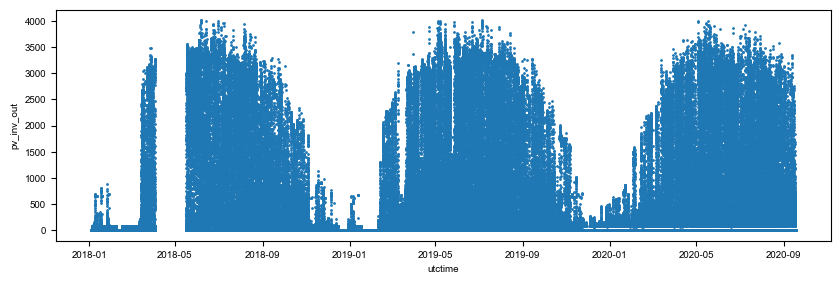

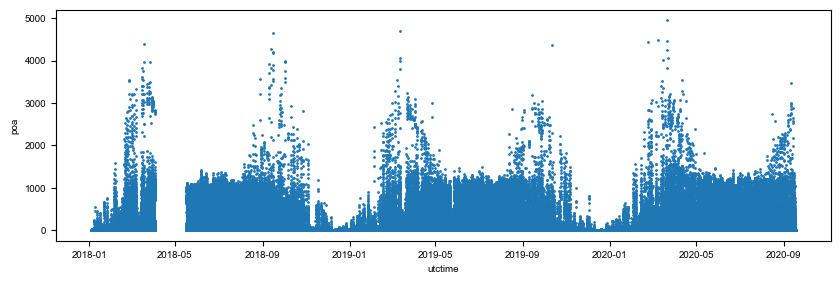

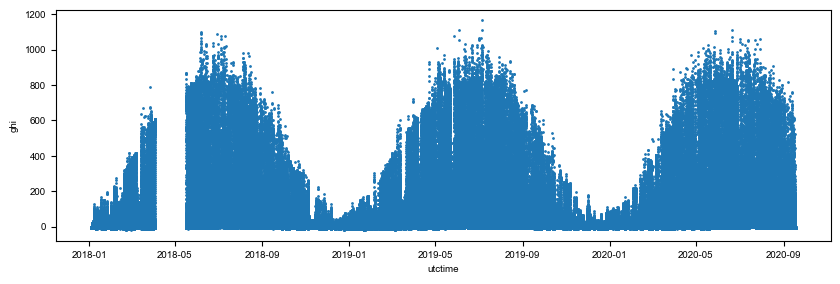

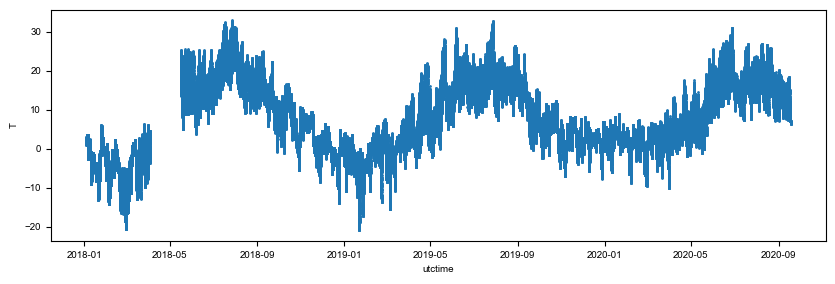

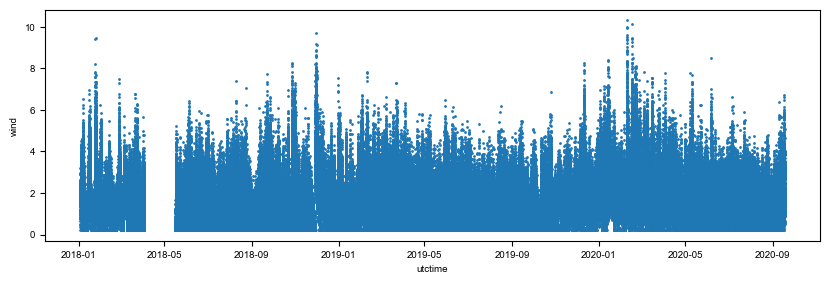

In [ ]:
data.plot(x='utctime', y='power', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='scatter', s=1, figsize=(10,3))
plt.show()

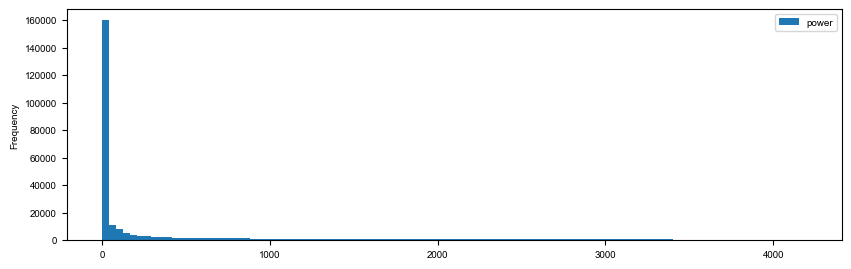

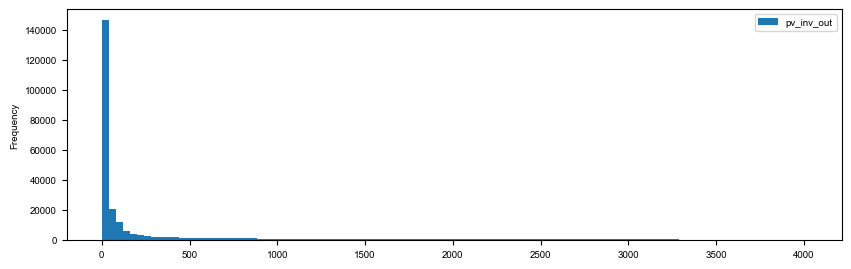

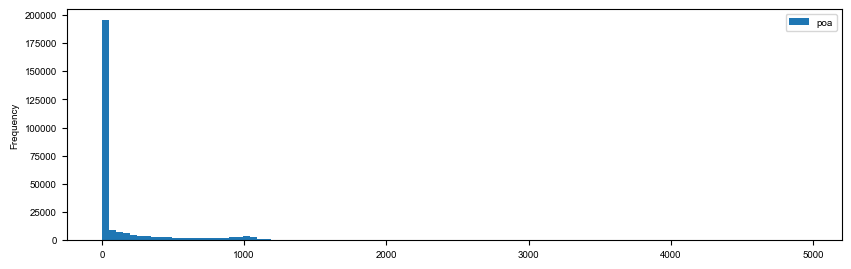

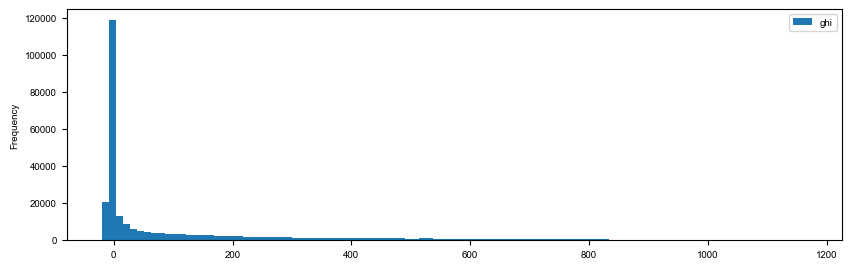

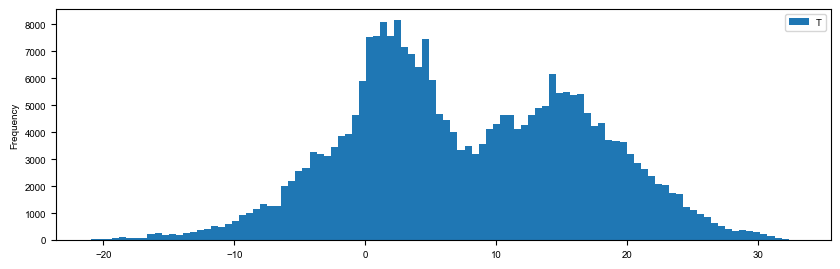

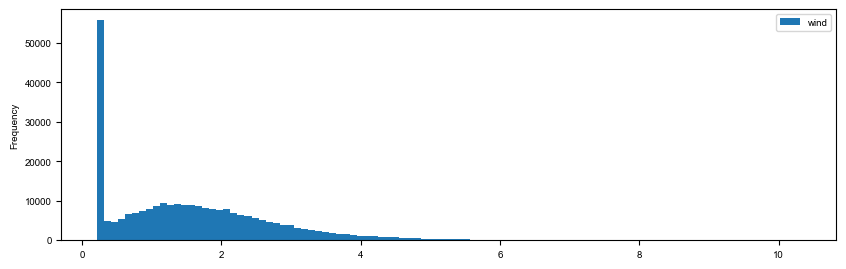

In [5]:
data.plot(x='utctime', y='power', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='hist', bins=100, figsize=(10,3))
plt.show()

## Initial filtering

First, let's apply nighttime filter and IEC threhold filters. The near-zero power line is filtered manually, since it is an obvious data quality issue. Additionally, since the POA's seem to reach unrealistic values over 1500 W/M^2, let's apply a irradiance threshold filter at 1200 W/m^2.

In [5]:
data_day = data[filters.daytime(data)]
# Filter for irradiance over 1200 W/m^2 and lower power line
threhshold_filter = filters.threshold(data_day, 'poa', upper=1200) & ~(filters.threshold(data_day, 'power', upper=100) & filters.threshold(data_day, 'poa', lower=100))

# All filters
all_filter_mask = filters.IEC(data_day, 4500) & threhshold_filter

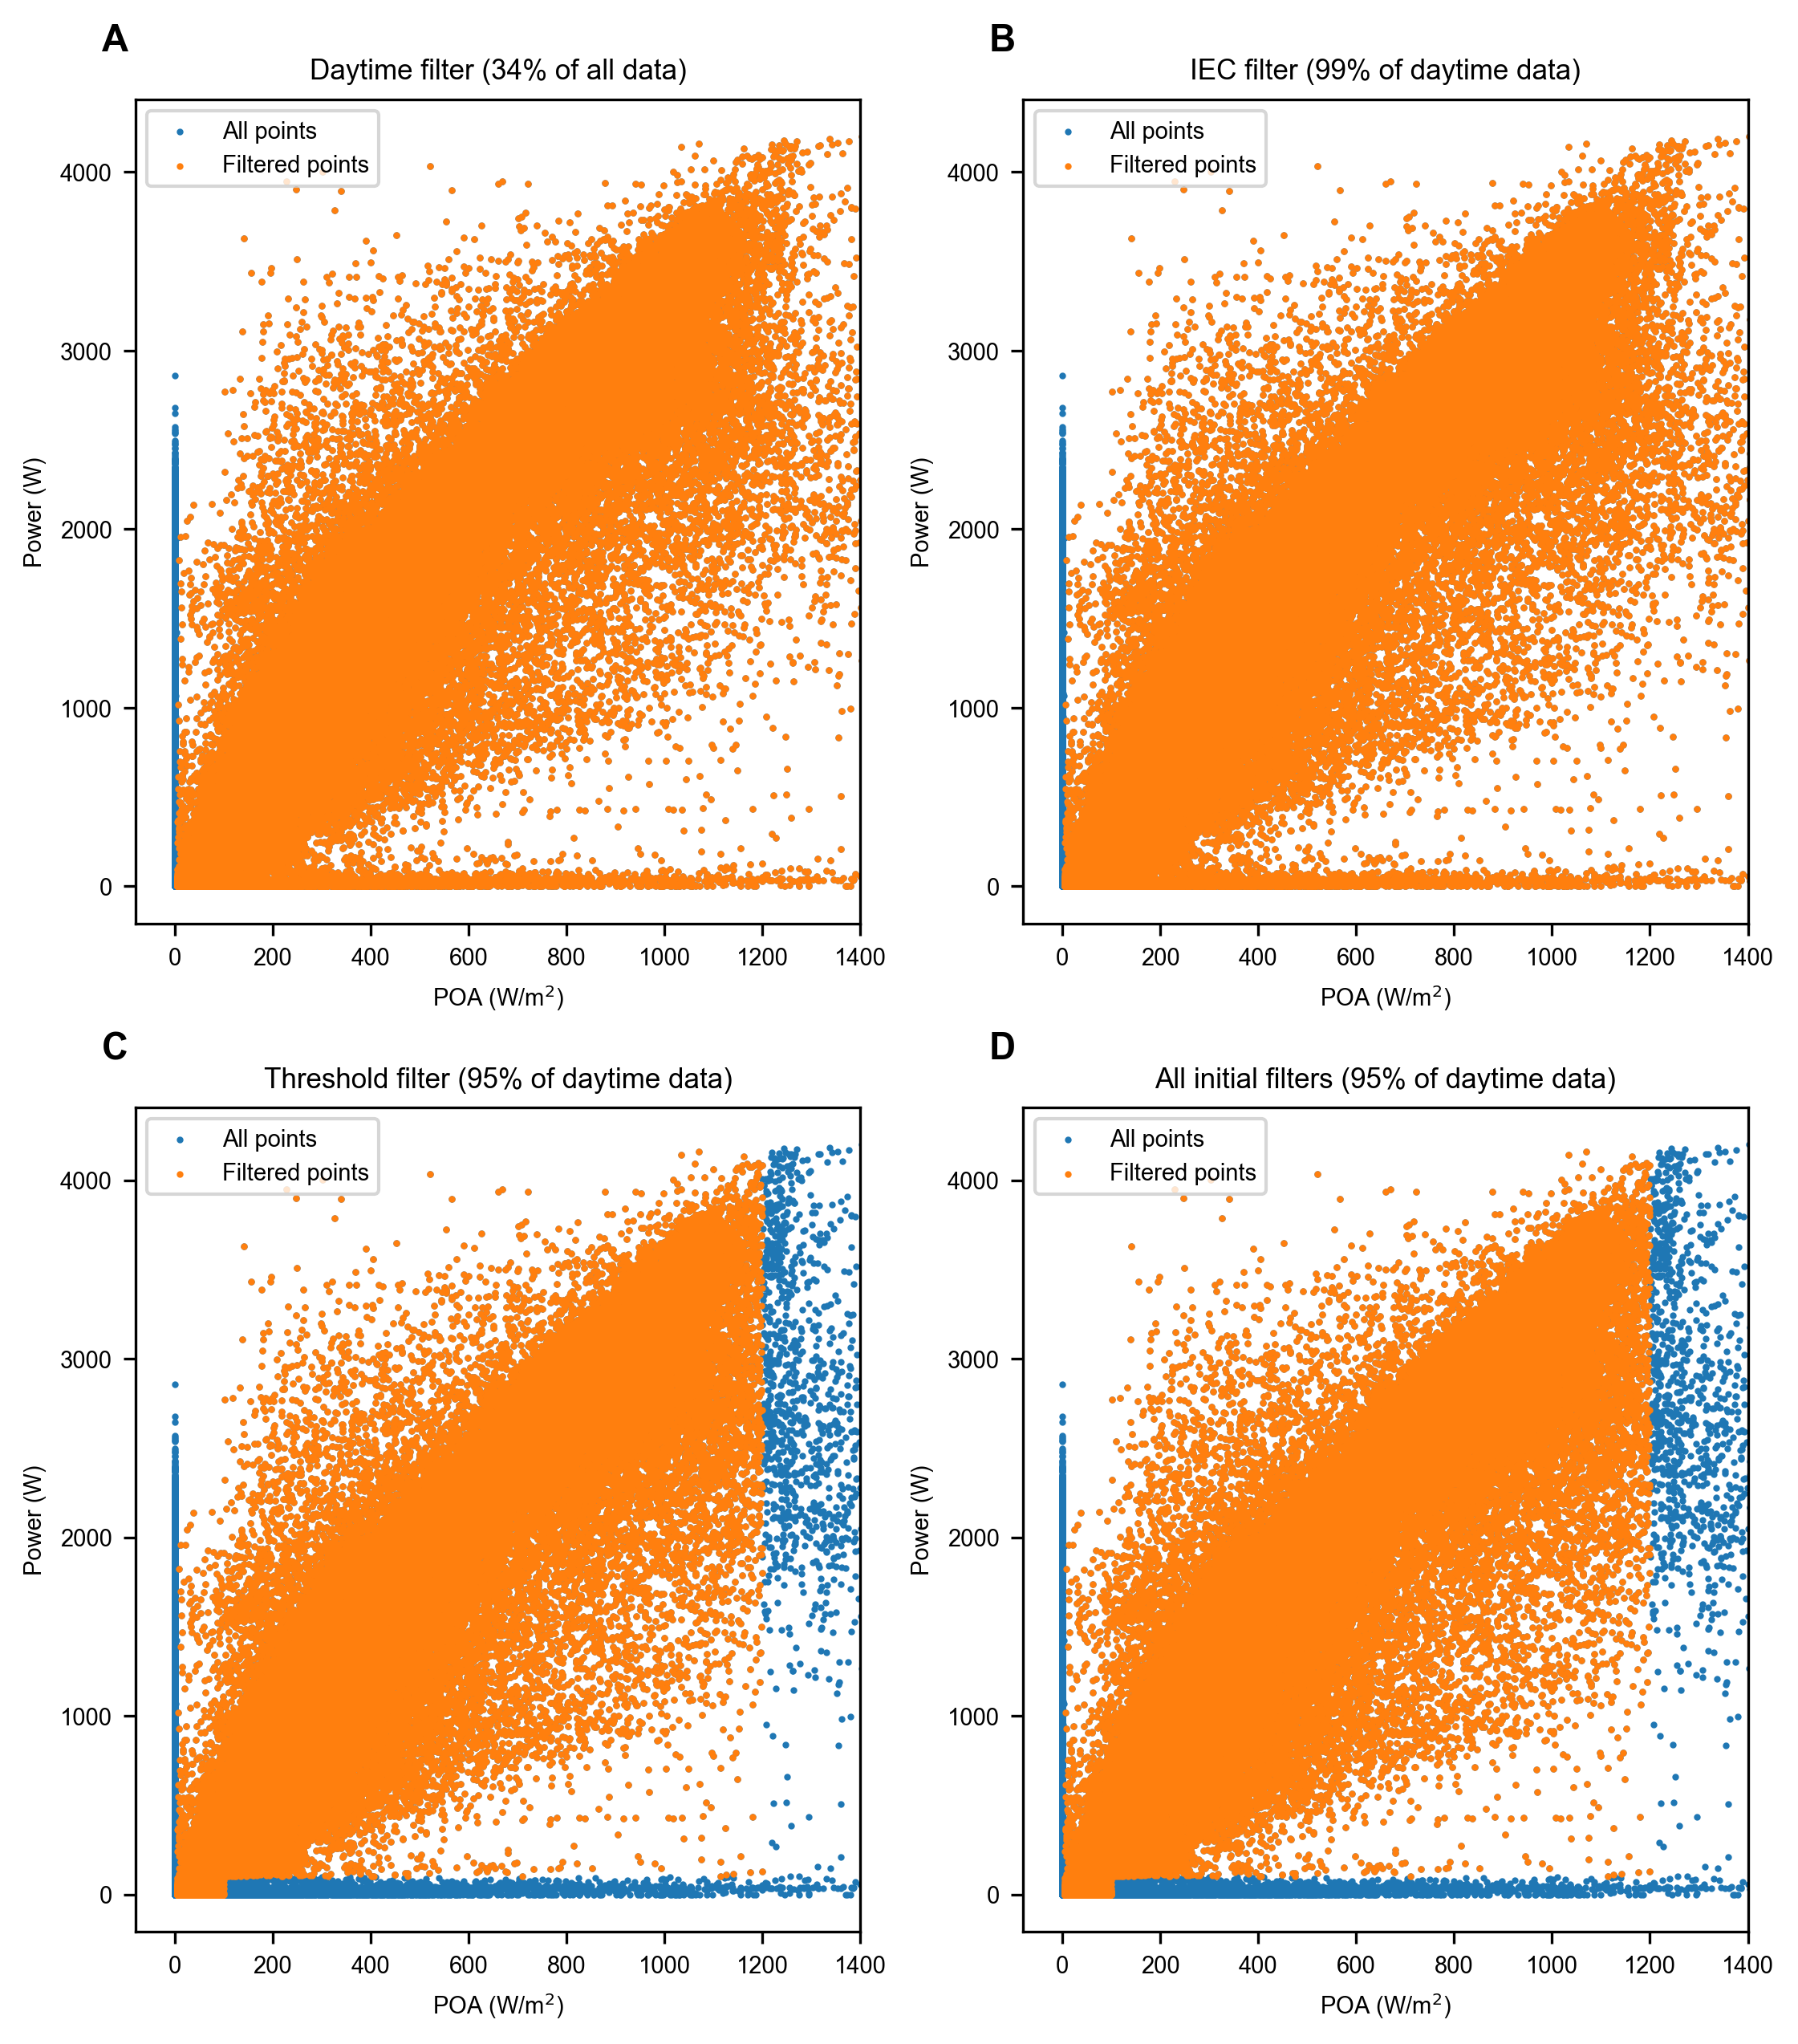

In [30]:
fig, ((ax0, ax1), (ax2, ax4)) = plt.subplots(2, 2, figsize=(2244/300,2544/300), dpi=300)

ax0.scatter(data['poa'], data['power'], s=1, label='All points')
ax0.scatter(data_day['poa'], data_day['power'], s=1, label='Filtered points')
ax0.set_xlabel(r'POA (W/m$^2$)')
ax0.set_ylabel('Power (W)')
ax0.set_title(f'Daytime filter ({(len(data_day)/len(data))*100:.0f}% of all data)')
ax0.legend(loc='upper left')

ax1.scatter(data['poa'], data['power'], s=1, label='All points')
ax1.scatter(data_day[filters.IEC(data_day, 4500)]['poa'], data_day[filters.IEC(data_day, 4500)]['power'], s=1, label='Filtered points')
ax1.set_xlabel(r'POA (W/m$^2$)')
ax1.set_ylabel('Power (W)')
ax1.set_title(f'IEC filter ({(len(data_day[filters.IEC(data_day, 4500)])/len(data_day))*100:.0f}% of daytime data)')
ax1.legend(loc='upper left')


ax2.scatter(data['poa'], data['power'], s=1, label='All points')
ax2.scatter(data_day[threhshold_filter]['poa'], data_day[threhshold_filter]['power'], s=1, label='Filtered points')
ax2.set_xlabel(r'POA (W/m$^2$)')
ax2.set_ylabel('Power (W)')
ax2.set_title(f'Threshold filter ({(len(data_day[threhshold_filter])/len(data_day))*100:.0f}% of daytime data)')
ax2.legend(loc='upper left')

# All filters
ax4.scatter(data['poa'], data['power'], s=1, label='All points')
ax4.scatter(data_day[all_filter_mask]['poa'], data_day[all_filter_mask]['power'], s=1, label='Filtered points')
ax4.set_xlabel(r'POA (W/m$^2$)')
ax4.set_ylabel('Power (W)')
ax4.set_title(f'All initial filters ({(len(data_day[all_filter_mask])/len(data_day))*100:.0f}% of daytime data)')
ax4.legend(loc='upper left')


for a, letter in list(zip([ax0, ax1, ax2, ax4], 
                        ['A', 'B', 'C', 'D'])):
    x0, xmax = a.set_xlim(-80, 1400)
    y0, ymax = a.set_ylim()
    data_width = xmax - x0
    data_height = ymax - y0
    a.text(x0-(0.01*data_width), (y0 + 1.05*data_height), letter, weight='bold', fontsize=11, va='bottom', ha='right')


plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'turku_south_initial_filters.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
plt.show()


## Outlier filtering
After initial filtering, there remains some outlying power-irradiance values, which should be removed for better performance analysis.

In [5]:
filter_mask = filters.daytime(data) & filters.IEC(data, 4500) & threhshold_filter
data_filtered = data[filter_mask]

### $\pm$ 2sd around instantaneous PR
This was used e.g., in [1]

[1]  https://doi.org/10.1002/pip.3397

In [32]:

# Get mean and standard deviation of P/POA (which is basically the same as PR)
data_filtered['p/poa'] = data.power / data.poa
p_poa_mean = data_filtered['p/poa'].mean()
p_poa_sd = data_filtered['p/poa'].std()
p_poa_mask = (data_filtered['p/poa'] > p_poa_mean - 2*p_poa_sd) & (data_filtered['p/poa'] < p_poa_mean + 2*p_poa_sd)

C:\Users\plkart\AppData\Local\Temp\ipykernel_16920\1398006881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['p/poa'] = data.power / data.poa


Share of data after filtering: 0.987


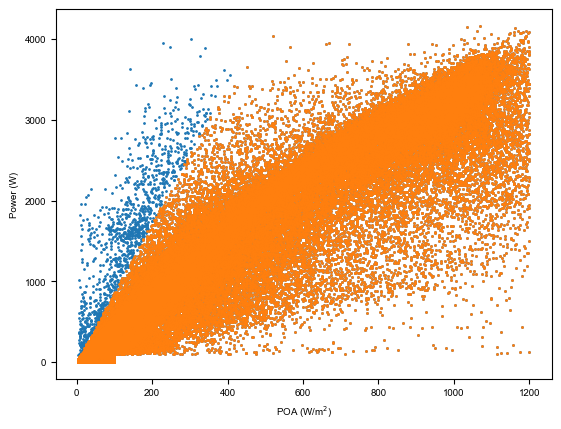

In [33]:
plt.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1)
plt.scatter(data_filtered[p_poa_mask]['poa'], data_filtered[p_poa_mask]['power'], s=1, alpha=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')

# Amount of data filtered
print('Share of data after filtering: {:.3f}'.format(len(data_filtered[p_poa_mask])/len(data_filtered)))


plt.show()

### Rolling window

Share of data after filtering compared with pre-filtered data: 0.809
Share of data after filtering compared with all daytime data: 0.766


C:\Users\plkart\AppData\Local\Temp\ipykernel_8452\1789544522.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_8452\1789544522.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_8452\1789544522.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


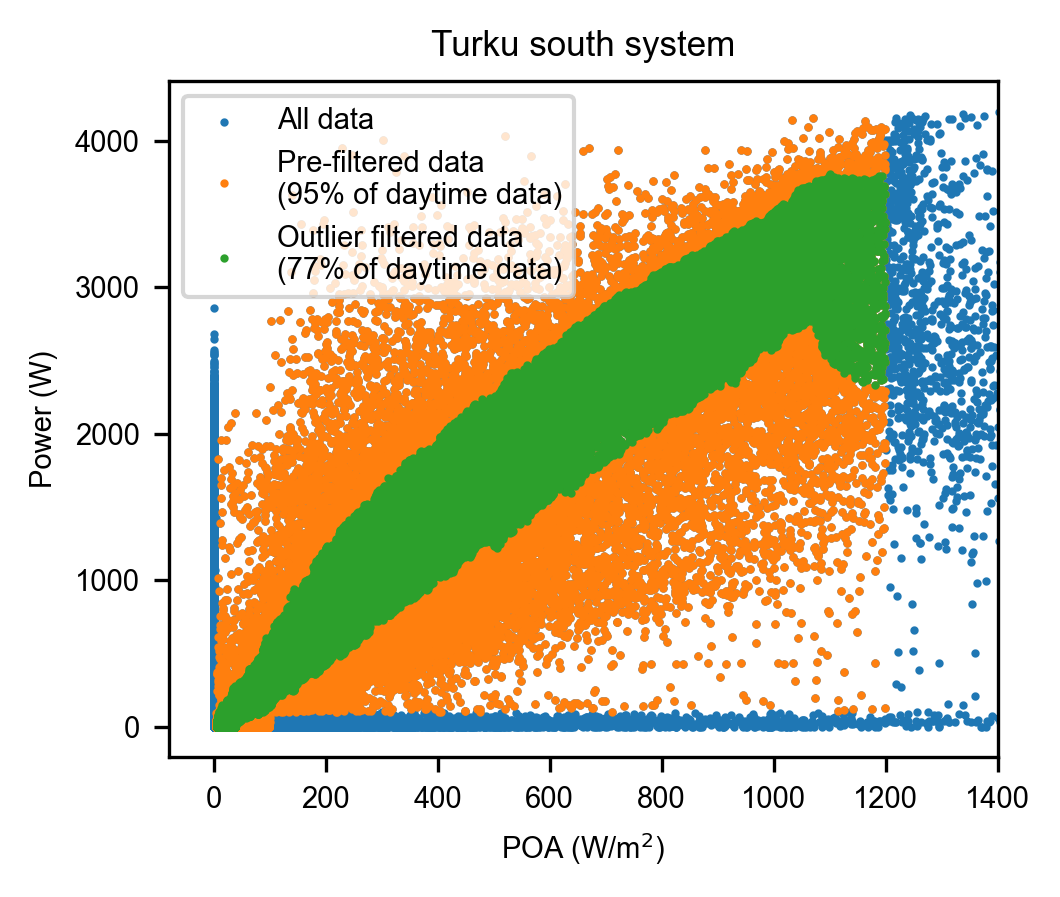

In [9]:
rolling_filter = filters.rolling_outlier_filter(data_filtered, 1000, 1)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[rolling_filter]['poa'], data_filtered[rolling_filter]['power'], s=1, alpha=1,
           label=f'Outlier filtered data\n({len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlim(-80, 1400)
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Turku south system')

# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'turku_south_outlier_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()

## Clear-sky filtering

In [6]:
filter_mask = filters.daytime(data) & filters.IEC(data, 4500) & threhshold_filter
data_filtered = data[filter_mask]

Share of data after filtering compared with pre-filtered data: 0.114
Share of data after filtering compared with all daytime data: 0.108


C:\Users\plkart\AppData\Local\Temp\ipykernel_14124\4003946286.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_14124\4003946286.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_14124\4003946286.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


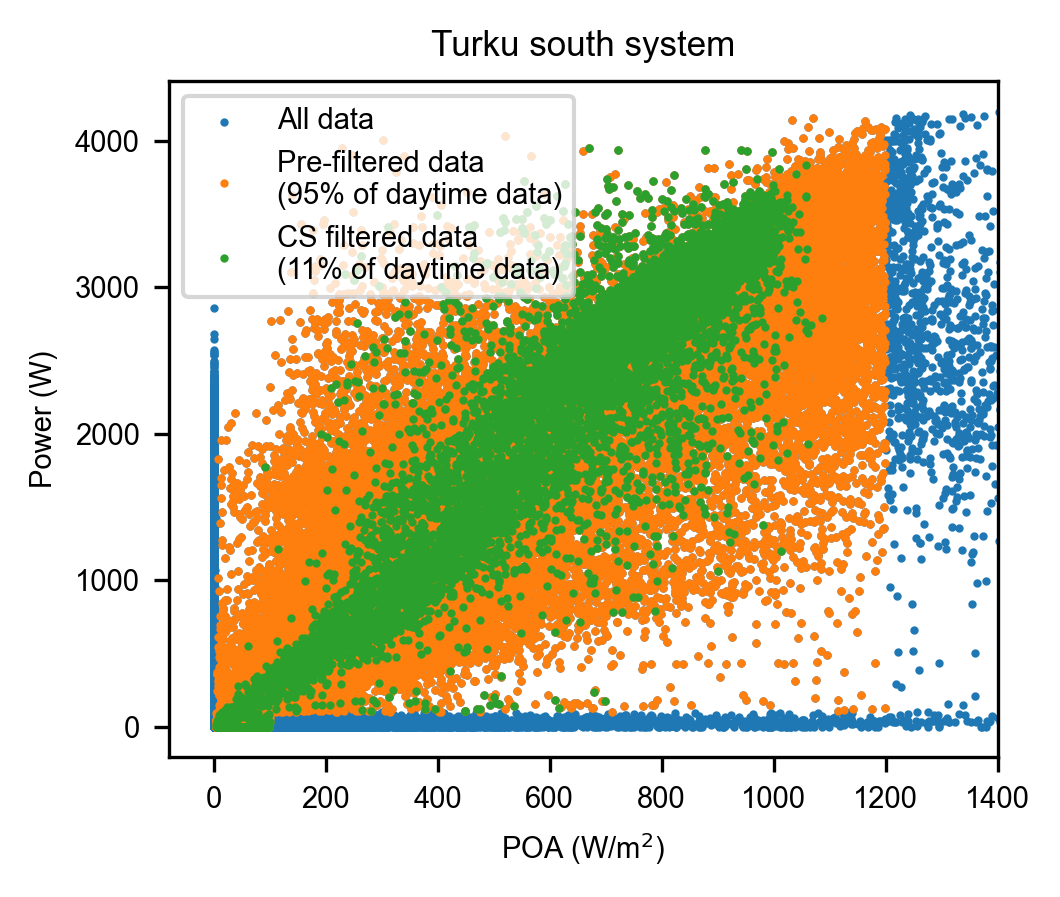

In [7]:
cs_filter = filters.clear_sky(data_filtered, latitude=config.latitude_turku, longitude=config.longitude_turku, 
                              altitude=config.elevation_turku)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[cs_filter]['poa'], data_filtered[cs_filter]['power'], s=1, alpha=1,
           label=f'CS filtered data\n({len(data_filtered[cs_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlim(-80, 1400)
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Turku south system')
# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'tukru_south_clearsky_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()